In [39]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from random import sample
import time
%matplotlib inline

In [40]:
#Load In Data 
x = np.loadtxt('X.txt', delimiter = ',')
y = np.loadtxt('Y.txt', delimiter = ',')

In [41]:
#1a. Linear Regression
start_time = time.time()
temp = np.linalg.inv(np.matmul(np.transpose(x), x)) #(X^TX)^-1
temp = np.matmul(temp, np.transpose(x)) #(X^TX)^-1X
w_linreg = np.matmul(temp, y) #w = (X^TX)^-1X^TY
finish_time = time.time() - start_time
print(finish_time)
w_linreg

0.0009629726409912109


array([-0.07882655,  2.04885018, -1.79061198])

In [4]:
#1b. Binary Classification
y_pred = np.matmul(x, w_linreg) #y = w^Tx. Note that this w is already transposed.
y_pred

array([-0.82296044,  0.21486641, -0.89987708,  1.58837084, -0.65321683,
        0.58608655,  0.10721304, -1.50361452, -0.83998271, -0.75307039,
       -0.48582752,  0.32930778, -0.68294   , -1.09136419, -1.32215708,
       -1.0107477 ,  0.02567095, -1.38496075, -0.43415134, -0.39895117,
        0.88964702, -0.90493062,  0.0483963 ,  0.11549781,  0.84106733,
        0.62798685, -1.39215269,  1.25654929, -0.09326011,  0.24653106,
        1.01352564, -0.36968253, -0.50835879,  1.36953203, -0.00261137,
        1.05912954,  0.97443671, -1.06443077,  0.79932874,  0.52610471])

In [5]:
#Sign Function
for i,j in enumerate(y_pred):
    if(y_pred[i] < 0):
        y_pred[i] = -1
    elif(y_pred[i] > 0):
        y_pred[i] = 1
    else:
        y_pred[i] = 0
y_pred

array([-1.,  1., -1.,  1., -1.,  1.,  1., -1., -1., -1., -1.,  1., -1.,
       -1., -1., -1.,  1., -1., -1., -1.,  1., -1.,  1.,  1.,  1.,  1.,
       -1.,  1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.,
        1.])

In [6]:
#Error Calculation
N_mistakes = 0
for i, j in enumerate(y):
    if(y[i] != y_pred[i]):
        N_mistakes += 1
print('Number of Mistakes: ' + str(N_mistakes))
print('Error Rate: ' + str(N_mistakes / y.size)) #N_mistakes divided by number of elements.

Number of Mistakes: 1
Error Rate: 0.025


In [42]:
#1c. PLA
#From Zero:
w_pla_base = np.zeros(len(x[0]))
temp = w_pla_base
N_iterations = 0
start_time = time.time()
for i in range(100): #100 iterations. Will break when perfect.
    temp = list(w_pla_base)
    N_iterations += 1
    for i, j in enumerate(x): #PLA Algorithm. 
        if(np.dot(w_pla_base, x[i]) * y[i]) <= 0: #w^Tx = Dot product. Multiply with y_linsep to get sign. 
            w_pla_base += x[i]*y[i] 
    if(np.array_equal(temp, w_pla_base)):
        break        
finish_time = time.time() - start_time
print(finish_time)
print(w_pla_base)
print('Number of Iterations: ' + str(N_iterations))

0.0020012855529785156
[ 0.      3.5303 -3.4182]
Number of Iterations: 5


In [43]:
#From w_linreg
w_pla_linreg = w_linreg
temp = w_pla_linreg
N_iterations = 0
start_time = time.time()
for i in range(100): #100 iterations. Will break when perfect.
    temp = list(w_pla_linreg)
    N_iterations += 1
    for i, j in enumerate(x): #PLA Algorithm. 
        if(np.dot(w_pla_linreg, x[i]) * y[i]) <= 0: #w^Tx = Dot product. Multiply with y_linsep to get sign. 
            w_pla_linreg += x[i]*y[i] 
    if(np.array_equal(temp, w_pla_linreg)):
        break
finish_time = time.time() - start_time
print(finish_time)
print(w_pla_linreg)
print('Number of Iterations: ' + str(N_iterations))

0.0009996891021728516
[-0.07882655  2.18205018 -2.01981198]
Number of Iterations: 2


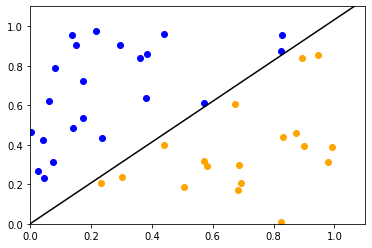

In [44]:
#Plotting PLA from zero
for i, j in enumerate(x):
    if(y[i] == 1):
        plt.scatter(x[i][1], x[i][2], c='orange') #y = 1. No need to include first element as it is all 1. 
    else:
        plt.scatter(x[i][1], x[i][2], c='blue') #y = 0
#Rotate w vector 90 degrees about the origin to get decision boundary. (x, y) -> (-y, x)
#Alternatively, compute -w[0]/w[2] and -w[1]/w[2] to get y-intercept and slope respectively. They should be identical for now. 
x_plot = [0, -w_pla_base[2]]
y_plot = [-w_pla_base[0]/w_pla_base[2], w_pla_base[1]]
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
plt.plot(x_plot, y_plot, c='black')

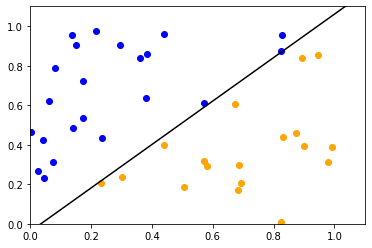

In [45]:
#Plotting PLA from w_linreg
for i, j in enumerate(x):
    if(y[i] == 1):
        plt.scatter(x[i][1], x[i][2], c='orange') #y = 1. No need to include first element as it is all 1. 
    else:
        plt.scatter(x[i][1], x[i][2], c='blue') #y = 0
#Rotate w vector 90 degrees about the origin to get decision boundary. (x, y) -> (-y, x)
#Alternatively, compute -w[0]/w[2] and -w[1]/w[2] to get y-intercept and slope respectively. They should be identical for now. 
x_plot = [0, -w_pla_linreg[2]]
y_plot = [-w_pla_linreg[0]/w_pla_linreg[2], w_pla_linreg[1]]
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
plt.plot(x_plot, y_plot, c='black')

In [46]:
#Error Checking From Zero.
N_mistakes = 0
for i, j in enumerate(x):
    if(np.dot(w_pla_base, x[i]) < 0 and y[i] != -1): #If sign(w^Tx = -1 and y_linsep does not equal -1)
        N_mistakes += 1
    elif(np.dot(w_pla_base, x[i]) > 0 and y[i] != 1): #If sign(w^Tx = 1 and y_linsep does not equal 1)
        N_mistakes += 1
print('Number of Mistakes: ' + str(N_mistakes))
print('Error Rate: ' + str(N_mistakes / y.size)) #N_mistakes divided by number of elements.

Number of Mistakes: 0
Error Rate: 0.0


In [47]:
#Error Checking From w_linreg
N_mistakes = 0
for i, j in enumerate(x):
    if(np.dot(w_pla_linreg, x[i]) < 0 and y[i] != -1): #If sign(w^Tx = -1 and y_linsep does not equal -1)
        N_mistakes += 1
    elif(np.dot(w_pla_linreg, x[i]) > 0 and y[i] != 1): #If sign(w^Tx = 1 and y_linsep does not equal 1)
        N_mistakes += 1
print('Number of Mistakes: ' + str(N_mistakes))
print('Error Rate: ' + str(N_mistakes / y.size)) #N_mistakes divided by number of elements.

Number of Mistakes: 0
Error Rate: 0.0


In [48]:
#2a. Logistic Regression
def sig(x):
    return 1 / (1 + np.exp(-x))

In [51]:
def logreg(x, y, w_init, training_rate, cutoff):
    w_logreg = w_init
    N_iterations = 0
    start_time = time.time()
    for i in range(10000): 
        gradient = np.zeros(len(x[0]))
        for i, j in enumerate(x):
            temp = -y[i] * np.transpose(w_logreg)
            temp = np.matmul(temp, x[i])
            gradient += sig(temp) * (y[i] * x[i]) #gradient = 1/N * sum(sig(-y(n)w(t)^Tx(n)) * (y(n)x(n)))
        gradient = gradient / y.size
        w_logreg += gradient * training_rate
        N_iterations += 1
        if(np.dot(gradient, gradient) ** 0.5 < cutoff):
            break
    finish_time = time.time() - start_time
    print(finish_time)
    print(N_iterations)
    return w_logreg

In [52]:
w_logreg = logreg(x, y, np.zeros(len(x[0])), 0.1, 0.01)
w_logreg

2.1378324031829834
4969


array([ 0.19525137,  8.76459382, -8.71859596])

In [53]:
#2b. Binary Classification
def binary_classification(x, w):
    y_pred = np.matmul(x, w) #y = sign(w^Tx). Note that this w is already transposed.
    #Sign Function
    for i,j in enumerate(y_pred):
        if(y_pred[i] < 0):
            y_pred[i] = -1
        elif(y_pred[i] > 0):
            y_pred[i] = 1
        else:
            y_pred[i] = 0
    N_mistakes = 0
    for i, j in enumerate(y):
        if(y[i] != y_pred[i]):
            N_mistakes += 1
    print('Number of Mistakes: ' + str(N_mistakes))
    print('Error Rate: ' + str(N_mistakes / y.size)) #N_mistakes divided by number of elements.
    return y_pred

In [54]:
binary_classification(x, w_logreg)

Number of Mistakes: 0
Error Rate: 0.0


array([-1.,  1., -1.,  1., -1.,  1.,  1., -1., -1., -1., -1.,  1., -1.,
       -1., -1., -1.,  1., -1., -1., -1.,  1., -1., -1.,  1.,  1.,  1.,
       -1.,  1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.,
        1.])

In [55]:
#2c. w_linreg as start
w_logreg_2 = logreg(x, y, w_linreg, 0.1, 0.01)
binary_classification(x, w_logreg_2)
w_logreg_2

2.04484224319458
4637
Number of Mistakes: 0
Error Rate: 0.0


array([ 0.19879413,  8.76076427, -8.7210634 ])

In [57]:
#2d. Testing other training rates.
w_logreg_test = logreg(x, y, np.zeros(len(x[0])), 0.5, 0.01)
binary_classification(x, w_logreg_test)

0.41405272483825684
994
Number of Mistakes: 0
Error Rate: 0.0


array([-1.,  1., -1.,  1., -1.,  1.,  1., -1., -1., -1., -1.,  1., -1.,
       -1., -1., -1.,  1., -1., -1., -1.,  1., -1., -1.,  1.,  1.,  1.,
       -1.,  1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.,
        1.])

In [58]:
#3a. SGD
def random_sample(n, x, y):
    insert = np.insert(x, 3, y, axis = 1)
    rows = np.random.choice(insert.shape[0], size=n, replace=False)
    sgd_list = insert[rows, :]
    y_sample = sgd_list[:, 3]
    x_sample = np.delete(sgd_list, 3, axis = 1)
    return x_sample, y_sample

In [59]:
x_sample, y_sample = random_sample(10, x, y)
print(x_sample)
print(y_sample)

[[1.     0.6748 0.6081]
 [1.     0.9802 0.3127]
 [1.     0.8748 0.4601]
 [1.     0.0629 0.6224]
 [1.     0.5071 0.1855]
 [1.     0.1515 0.9068]
 [1.     0.8316 0.4378]
 [1.     0.1373 0.9528]
 [1.     0.0413 0.4238]
 [1.     0.8241 0.8719]]
[ 1.  1.  1. -1.  1. -1.  1. -1. -1. -1.]


In [60]:
w_sgd = logreg(x_sample, y_sample, np.zeros(len(x[0])), 0.1, 0.01)
w_sgd

0.560039758682251
4620


array([ 1.1824098 ,  7.27415254, -9.03661125])

In [61]:
#3b. Binary Classification
binary_classification(x, w_sgd)

Number of Mistakes: 0
Error Rate: 0.0


array([-1.,  1., -1.,  1., -1.,  1.,  1., -1., -1., -1., -1.,  1., -1.,
       -1., -1., -1.,  1., -1., -1., -1.,  1., -1., -1.,  1.,  1.,  1.,
       -1.,  1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.,
        1.])

In [63]:
#3c. Testing different sample sizes.
x_sample, y_sample = random_sample(30, x, y)
w_sgd_test = logreg(x_sample, y_sample, np.zeros(len(x[0])), 0.1, 0.01)
print(w_sgd_test)
binary_classification(x, w_sgd_test)

1.5964035987854004
4913
[-0.58535142  9.10621996 -8.178015  ]
Number of Mistakes: 1
Error Rate: 0.025


array([-1.,  1., -1.,  1., -1.,  1.,  1., -1., -1., -1., -1.,  1., -1.,
       -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1.,  1.,  1.,  1.,
       -1.,  1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.,
        1.])